# Speaker repertoires and speaker types from segment-level DIME scores

This notebook analyzes segment-level DIME scores at the speaker level. The workflow comprises:

1. loading and cleaning the segment table,
2. filtering speakers with sufficient data in WSS, WSD, and FG,
3. aggregating scores by speaker and recording condition,
4. deriving speaker-specific thresholds from WSS and WSD,
5. describing temporal dynamics in FG,
6. classifying speaker profiles,
7. producing descriptive summaries and visualizations.

The notebook is deliberately self-contained. All paths and analysis parameters are defined in a central configuration cell.

> **Important assumption about minimum duration:** Minimum duration is approximated by the number of segments. With overlapping windows, `count × segment length` does not equal the actual observed audio duration.


In [1]:
from pathlib import Path
import json
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import iqr
from typing import Optional
from sklearn.metrics import accuracy_score, adjusted_rand_score, cohen_kappa_score


## 2. Configuration

Only this cell needs to be adapted to a different environment. The input table is expected to contain at least the following columns:

- `speaker`: speaker ID,
- `recording_condition`: recording condition,
- `combined_score`: segment-level DIME score,
- `samples_begin`, `samples_end`: segment boundaries in samples,
- `dialect`: dialect region used in the final dialect-level summary.

The labels `standard` and `dialect` are mapped to `WSS` and `WSD`, respectively.


In [ ]:
# Input and output paths
INPUT_CSV = Path(r"...\BT_10s\dialectality_segment_scores.csv")
OUTPUT_DIR = Path(r"...\BT_10s")

# Column names
SPEAKER_COL = "speaker"
SITUATION_COL = "recording_condition"
SCORE_COL = "combined_score"
DIALECT_COL = "dialect"
START_SAMPLE_COL = "samples_begin"
END_SAMPLE_COL = "samples_end"

# Audio and segment parameters
SEGMENT_LENGTH_SECONDS = 10
REFERENCE_SEGMENT_LENGTH_SECONDS = 10
REFERENCE_SPEAKERS_FILE = (OUTPUT_DIR.parent / "eligible_speakers_reference_10s.json")
SAMPLE_RATE = 16_000
VALID_SITUATIONS = ("WSS", "WSD", "FG")
SITUATION_MAPPING = {
    "standard": "WSS",
    "dialect": "WSD",
    "FG": "FG",
}

# Minimum coverage per speaker and condition
MINIMUM_DURATION_SECONDS = {
    "WSS": 50,
    "WSD": 50,
    "FG": 100,
}

# Speaker-type classification thresholds
REPERTOIRE_CUTOFF_QUANTILE = 0.25
FG_POLARIZATION_CUTOFF = 0.80
MIN_EXTREME_PROPORTION = 0.20

# Reproducibility and export
RANDOM_STATE = 1157

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## 3. Load and clean the data

The function first validates the input schema. It then normalizes IDs and recording-condition labels, removes non-finite scores, and adds segment times in seconds.


In [3]:
def require_columns(frame: pd.DataFrame, required_columns: set[str]) -> None:
    """Raise a clear error if required input columns are missing."""
    missing = required_columns.difference(frame.columns)
    if missing:
        raise ValueError(f"Missing columns in the input table: {sorted(missing)}")


def load_segment_scores(path: Path) -> pd.DataFrame:
    """Load and standardize the segment-level DIME table."""
    frame = pd.read_csv(path).copy()

    require_columns(
        frame,
        {
            SPEAKER_COL,
            SITUATION_COL,
            SCORE_COL,
            START_SAMPLE_COL,
            END_SAMPLE_COL,
        },
    )

    frame[SPEAKER_COL] = frame[SPEAKER_COL].astype(str).str.strip()
    frame[SITUATION_COL] = frame[SITUATION_COL].astype(str).str.strip()
    frame[SCORE_COL] = pd.to_numeric(frame[SCORE_COL], errors="coerce")
    frame[START_SAMPLE_COL] = pd.to_numeric(frame[START_SAMPLE_COL], errors="coerce")
    frame[END_SAMPLE_COL] = pd.to_numeric(frame[END_SAMPLE_COL], errors="coerce")

    frame = frame.replace([np.inf, -np.inf], np.nan)
    frame = frame.dropna(
        subset=[
            SPEAKER_COL,
            SITUATION_COL,
            SCORE_COL,
            START_SAMPLE_COL,
            END_SAMPLE_COL,
        ]
    ).copy()

    frame[SITUATION_COL] = frame[SITUATION_COL].replace(SITUATION_MAPPING)
    frame = frame[frame[SITUATION_COL].isin(VALID_SITUATIONS)].copy()

    frame["start_sec"] = frame[START_SAMPLE_COL] / SAMPLE_RATE
    frame["end_sec"] = frame[END_SAMPLE_COL] / SAMPLE_RATE
    frame["mid_sec"] = (frame["start_sec"] + frame["end_sec"]) / 2

    return frame


segments = load_segment_scores(INPUT_CSV)
print(f"Loaded segments: {len(segments):,}")
segments.head()

Loaded segments: 25,289


,dialect,file_name,file_path,speaker,samples_begin,samples_end,recording_condition,generation,distance_to_standard_center,distance_z,projection_z,combined_score,start_sec,end_sec,mid_sec
0,Bavarian,AM2_FG.wav,D:\Tonaufnahmen\NEUERHEBUNG_all_cut\Bairisch\A...,AM2,0,159999,FG,MITTEL,12.685152,1.503326,2.120370,1.904405,0.0,9.999937,4.999969
1,Bavarian,AM2_FG.wav,D:\Tonaufnahmen\NEUERHEBUNG_all_cut\Bairisch\A...,AM2,160000,319999,FG,MITTEL,14.906372,2.450365,2.174787,2.271240,10.0,19.999938,14.999969
2,Bavarian,AM2_FG.wav,D:\Tonaufnahmen\NEUERHEBUNG_all_cut\Bairisch\A...,AM2,320000,479999,FG,MITTEL,13.581022,1.885289,1.738227,1.789699,20.0,29.999938,24.999969
3,Bavarian,AM2_FG.wav,D:\Tonaufnahmen\NEUERHEBUNG_all_cut\Bairisch\A...,AM2,480000,639999,FG,MITTEL,14.867779,2.433911,2.012678,2.160109,30.0,39.999938,34.999969
4,Bavarian,AM2_FG.wav,D:\Tonaufnahmen\NEUERHEBUNG_all_cut\Bairisch\A...,AM2,640000,799999,FG,MITTEL,11.822205,1.135400,2.331814,1.913069,40.0,49.999938,44.999969


## 4. Filter speakers by minimum data coverage

The required minimum duration is approximated by a minimum number of complete segments.


In [ ]:
def filter_speakers_using_10s_reference(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Define the speaker sample using the 10-second segmentation and reuse
    exactly that sample for all other segment lengths.

    For SEGMENT_LENGTH_SECONDS == 10:
        Determine eligible speakers using the minimum-segment criterion
        and save their identifiers.

    For all other segment lengths:
        Load the speaker identifiers selected in the 10-second analysis
        and filter the data to exactly those speakers.
    """
    required_columns = {
        SPEAKER_COL,
        SITUATION_COL,
    }

    missing_columns = required_columns.difference(frame.columns)

    if missing_columns:
        raise ValueError(
            "Missing columns for speaker filtering: "
            f"{sorted(missing_columns)}"
        )

    # Segment counts are calculated for diagnostics at every segment length.
    segment_counts = (
        frame.groupby([SPEAKER_COL, SITUATION_COL], observed=True,)
        .size()
        .unstack(fill_value=0)
        .reindex(columns=VALID_SITUATIONS, fill_value=0)
    )

    if SEGMENT_LENGTH_SECONDS == REFERENCE_SEGMENT_LENGTH_SECONDS:
        # -------------------------------------------------------------
        # Baseline run: determine the reference sample from 10 s segments
        # -------------------------------------------------------------
        minimum_segments = {
            situation: math.ceil(duration / SEGMENT_LENGTH_SECONDS)
            for situation, duration in MINIMUM_DURATION_SECONDS.items()
        }

        valid_mask = pd.Series(
            True,
            index=segment_counts.index,
            dtype=bool,
        )

        for situation in VALID_SITUATIONS:
            valid_mask &= (
                segment_counts[situation]
                >= minimum_segments[situation]
            )

        valid_speakers = segment_counts.index[
            valid_mask
        ]

        reference_speaker_ids = sorted(
            str(speaker)
            for speaker in valid_speakers
        )

        if not reference_speaker_ids:
            raise ValueError(
                "No speakers satisfy the minimum-segment criterion "
                "in the 10-second reference analysis."
            )

        reference_payload = {
            "reference_segment_length_seconds": (
                REFERENCE_SEGMENT_LENGTH_SECONDS
            ),
            "minimum_duration_seconds": {
                str(situation): float(duration)
                for situation, duration
                in MINIMUM_DURATION_SECONDS.items()
            },
            "minimum_segments_at_reference_length": {
                str(situation): int(count)
                for situation, count
                in minimum_segments.items()
            },
            "number_of_speakers": len(
                reference_speaker_ids
            ),
            "speakers": reference_speaker_ids,
        }

        REFERENCE_SPEAKERS_FILE.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        REFERENCE_SPEAKERS_FILE.write_text(
            json.dumps(
                reference_payload,
                indent=2,
                ensure_ascii=False,
            ),
            encoding="utf-8",
        )

        print(
            "Created 10-second reference sample:"
        )
        print(
            f"  speakers: {len(reference_speaker_ids)}"
        )
        print(
            f"  minimum segments: {minimum_segments}"
        )
        print(
            f"  saved to: {REFERENCE_SPEAKERS_FILE}"
        )

    else:
        # -------------------------------------------------------------
        # Sensitivity run: load the fixed sample from the 10 s analysis
        # -------------------------------------------------------------
        if not REFERENCE_SPEAKERS_FILE.exists():
            raise FileNotFoundError(
                "The 10-second reference speaker file does not exist:\n"
                f"{REFERENCE_SPEAKERS_FILE}\n\n"
                "Run the notebook once with "
                "SEGMENT_LENGTH_SECONDS = 10 first."
            )

        reference_payload = json.loads(
            REFERENCE_SPEAKERS_FILE.read_text(
                encoding="utf-8"
            )
        )

        stored_reference_length = reference_payload.get(
            "reference_segment_length_seconds"
        )

        if (
            stored_reference_length
            != REFERENCE_SEGMENT_LENGTH_SECONDS
        ):
            raise ValueError(
                "The stored speaker reference was not created "
                f"with {REFERENCE_SEGMENT_LENGTH_SECONDS}-second "
                "segments."
            )

        stored_minimum_durations = {
            str(situation): float(duration)
            for situation, duration in reference_payload[
                "minimum_duration_seconds"
            ].items()
        }

        current_minimum_durations = {
            str(situation): float(duration)
            for situation, duration
            in MINIMUM_DURATION_SECONDS.items()
        }

        if (
            stored_minimum_durations
            != current_minimum_durations
        ):
            raise ValueError(
                "MINIMUM_DURATION_SECONDS differs from the settings "
                "used to create the 10-second reference sample.\n"
                f"Stored: {stored_minimum_durations}\n"
                f"Current: {current_minimum_durations}\n\n"
                "Regenerate the reference file with the 10-second "
                "segmentation."
            )

        reference_speaker_ids = [
            str(speaker)
            for speaker in reference_payload["speakers"]
        ]

        print(
            "Loaded fixed 10-second reference sample:"
        )
        print(
            f"  speakers: {len(reference_speaker_ids)}"
        )
        print(
            f"  current segment length: "
            f"{SEGMENT_LENGTH_SECONDS} s"
        )
        print(
            f"  loaded from: {REFERENCE_SPEAKERS_FILE}"
        )

    # -----------------------------------------------------------------
    # Apply the same reference sample at every segment length
    # -----------------------------------------------------------------
    reference_speaker_set = set(
        reference_speaker_ids
    )

    frame_speaker_ids = frame[
        SPEAKER_COL
    ].astype(str)

    available_speaker_ids = set(
        frame_speaker_ids.unique()
    )

    completely_missing_speakers = sorted(
        reference_speaker_set
        - available_speaker_ids
    )

    if completely_missing_speakers:
        raise ValueError(
            "Some speakers from the fixed 10-second reference sample "
            "are completely absent from the current segmentation:\n"
            f"{completely_missing_speakers}\n\n"
            "The same speaker sample therefore cannot be constructed."
        )

    filtered_frame = frame.loc[
        frame_speaker_ids.isin(
            reference_speaker_set
        )
    ].copy()

    # -----------------------------------------------------------------
    # Verify that every reference speaker has data in every situation
    # -----------------------------------------------------------------
    presence_table = (
        filtered_frame.assign(
            _reference_speaker_id=filtered_frame[
                SPEAKER_COL
            ].astype(str)
        )
        .groupby(
            [
                "_reference_speaker_id",
                SITUATION_COL,
            ],
            observed=True,
        )
        .size()
        .unstack(fill_value=0)
        .reindex(
            index=reference_speaker_ids,
            columns=VALID_SITUATIONS,
            fill_value=0,
        )
    )

    missing_situation_mask = presence_table.eq(0)

    missing_speaker_situations = [
        (speaker, situation)
        for speaker, situation in (
            missing_situation_mask
            .stack()
            .loc[lambda values: values]
            .index
            .tolist()
        )
    ]

    if missing_speaker_situations:
        formatted_missing = "\n".join(
            f"  {speaker}: {situation}"
            for speaker, situation
            in missing_speaker_situations
        )

        raise ValueError(
            "Some reference speakers have no segments in one or more "
            "situations at the current segment length:\n"
            f"{formatted_missing}"
        )

    # Restrict the diagnostic count table to the reference sample.
    selected_count_mask = (
        segment_counts.index
        .map(str)
        .isin(reference_speaker_set)
    )

    selected_segment_counts = segment_counts.loc[
        selected_count_mask
    ].copy()

    print(
        f"Final fixed sample: "
        f"{filtered_frame[SPEAKER_COL].nunique()} speakers"
    )

    return filtered_frame, selected_segment_counts


segments, segment_counts = (filter_speakers_using_10s_reference(segments))
segments[SITUATION_COL].value_counts()

Created 10-second reference sample:
  speakers: 230
  minimum segments: {'WSS': 5, 'WSD': 5, 'FG': 10}
  saved to: D:\Ergebnisse\218_Width\Distance_and_v_from_WSS\BT_same_length\eligible_speakers_reference_10s.json
Final fixed sample: 230 speakers


FG     6106
WSD    3804
WSS    3788
Name: recording_condition, dtype: int64

## 5. Descriptive statistics by recording condition

The first table summarizes all segments within each recording condition. The second table contains one row per speaker and recording condition and serves as the basis for the subsequent analyses.


In [5]:
situation_statistics = (
    segments.groupby(SITUATION_COL)[SCORE_COL]
    .agg(
        n_segments="size",
        mean="mean",
        median="median",
        std="std",
        q05=lambda values: np.quantile(values, 0.05),
        q25=lambda values: np.quantile(values, 0.25),
        q75=lambda values: np.quantile(values, 0.75),
        q95=lambda values: np.quantile(values, 0.95),
        iqr=lambda values: iqr(values, nan_policy="omit"),
    )
    .reset_index()
)

situation_statistics

,recording_condition,n_segments,mean,median,std,q05,q25,q75,q95,iqr
0,FG,6106,0.891165,0.836886,0.883005,-0.456176,0.267678,1.464510,2.430499,1.196832
1,WSD,3804,1.282533,1.224622,1.010179,-0.320461,0.561722,1.963929,3.018308,1.402207
2,WSS,3788,0.264337,0.193508,0.778994,-0.865328,-0.295184,0.752845,1.655356,1.048029


In [6]:
speaker_situation_scores = (
    segments.groupby([SPEAKER_COL, SITUATION_COL])[SCORE_COL]
    .agg(
        score_median="median",
        score_mean="mean",
        score_std="std",
        score_iqr=lambda values: iqr(values, nan_policy="omit"),
        score_q05=lambda values: np.quantile(values, 0.05),
        score_q95=lambda values: np.quantile(values, 0.95),
        n_segments="size",
    )
    .reset_index()
)

segment_count_summary = (
    speaker_situation_scores.groupby(SITUATION_COL)["n_segments"]
    .agg(median="median", mean="mean", std="std")
    .reset_index()
)

speaker_median_summary = (
    speaker_situation_scores.groupby(SITUATION_COL)["score_median"]
    .agg(median="median", mean="mean", std="std")
    .reset_index()
)

speaker_situation_scores.head()

,speaker,recording_condition,score_median,score_mean,score_std,score_iqr,score_q05,score_q95,n_segments
0,A5,FG,1.176641,1.287277,0.764676,0.688623,0.199021,2.487244,28
1,A5,WSD,1.238325,1.235967,0.543184,0.447564,0.649687,2.052218,13
2,A5,WSS,0.730771,0.760484,0.510113,0.653403,0.091001,1.617432,20
3,AA2,FG,2.448917,2.403478,0.663424,0.814523,1.517600,3.566026,30
4,AA2,WSD,3.019528,2.810435,0.616133,0.849126,1.853268,3.561274,14


## 6. Speaker-specific reference ranges

For each speaker, two poles of the individual repertoire are estimated:

- **lower pole:** the 10th percentile and median of the WSS segments,
- **upper pole:** the 90th percentile and median of the WSD segments.

In [7]:
def compute_speaker_thresholds(frame: pd.DataFrame) -> pd.DataFrame:
    """Compute WSS and WSD reference quantiles for every speaker."""
    wss_thresholds = (
        frame.loc[frame[SITUATION_COL] == "WSS"]
        .groupby(SPEAKER_COL)[SCORE_COL]
        .quantile([0.10, 0.50])
        .unstack()
        .rename(columns={0.10: "speaker_wss_q10", 0.50: "speaker_wss_median"})
        .reset_index()
    )

    wsd_thresholds = (
        frame.loc[frame[SITUATION_COL] == "WSD"]
        .groupby(SPEAKER_COL)[SCORE_COL]
        .quantile([0.90, 0.50])
        .unstack()
        .rename(columns={0.90: "speaker_wsd_q90", 0.50: "speaker_wsd_median"})
        .reset_index()
    )

    return wss_thresholds.merge(wsd_thresholds, on=SPEAKER_COL, how="inner")


speaker_thresholds = compute_speaker_thresholds(segments)
speaker_thresholds.head()

,speaker,speaker_wss_q10,speaker_wss_median,speaker_wsd_median,speaker_wsd_q90
0,A5,0.173365,0.730771,1.238325,1.575052
1,AA2,-0.417210,0.279208,3.019528,3.477093
2,AAALT2,0.282008,0.944921,2.207160,2.772496
3,AC4,-0.654539,-0.097432,2.123010,2.452310
4,ACALT2,-0.419180,0.279896,2.155373,3.027070


## 7. Features of FG dynamics

Each FG segment is assigned a state relative to the speaker-specific WSS and WSD medians:

- `L`: at or below the WSS median,
- `H`: at or above the WSD median,
- `M`: between the two thresholds.

A middle segment is treated as a **transition** when it occurs directly between `L` and `H`, or between `H` and `L`; longer sequences containing several consecutive `M` segments are not marked as transitions.

The `fg_polarization_ratio` is the proportion of extreme segments among all extreme and stable-middle segments. Transitional middle segments are excluded from the denominator.


In [8]:
def label_fg_states(
    scores: np.ndarray,
    low_threshold: float,
    high_threshold: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Assign low/middle/high states and identify isolated transition middles."""
    states = np.full(len(scores), "M", dtype=object)
    states[scores <= low_threshold] = "L"
    states[scores >= high_threshold] = "H"

    middle_transition = np.zeros(len(scores), dtype=bool)
    for index in range(1, len(scores) - 1):
        if states[index] != "M":
            continue
        neighbours = (states[index - 1], states[index + 1])
        if neighbours in {("L", "H"), ("H", "L")}:
            middle_transition[index] = True

    middle_stable = (states == "M") & ~middle_transition
    return states, middle_transition, middle_stable


def build_speaker_features(
    frame: pd.DataFrame,
    aggregated_scores: pd.DataFrame,
    thresholds: pd.DataFrame,
) -> pd.DataFrame:
    """Construct repertoire and FG-dynamics features per speaker."""
    wide_scores = aggregated_scores.pivot(
        index=SPEAKER_COL,
        columns=SITUATION_COL,
        values="score_median",
    )
    wide_scores = wide_scores.reindex(columns=VALID_SITUATIONS)
    wide_scores.columns = [f"median_{condition}" for condition in wide_scores.columns]
    wide_scores = wide_scores.reset_index()

    condition_columns = ["median_FG", "median_WSS", "median_WSD"]
    wide_scores["median_span_all_conditions"] = (
        wide_scores[condition_columns].max(axis=1)
        - wide_scores[condition_columns].min(axis=1)
    )
    wide_scores["middle_condition"] = wide_scores[condition_columns].apply(
        lambda row: sorted(row.items(), key=lambda item: item[1])[1][0],
        axis=1,
    )

    threshold_index = thresholds.set_index(SPEAKER_COL)

    def summarize_fg(group: pd.DataFrame, speaker: str) -> pd.Series:
        group = group.sort_values("mid_sec")
        speaker_reference = threshold_index.loc[speaker]

        scores = group[SCORE_COL].to_numpy(dtype=float)
        low_threshold = float(speaker_reference["speaker_wss_median"])
        high_threshold = float(speaker_reference["speaker_wsd_median"])

        states, middle_transition, middle_stable = label_fg_states(
            scores,
            low_threshold,
            high_threshold,
        )

        low = states == "L"
        high = states == "H"
        extreme = low | high
        low_proportion = float(np.mean(low))
        high_proportion = float(np.mean(high))

        both_extremes = (
            low_proportion >= MIN_EXTREME_PROPORTION
            and high_proportion >= MIN_EXTREME_PROPORTION
        )

        denominator = np.mean(extreme) + np.mean(middle_stable)
        polarization_ratio = (
            float(np.mean(extreme) / denominator)
            if denominator > 0
            else np.nan
        )

        return pd.Series(
            {
                # Difference between WSD Q90 and WSS Q10.
                "repertoire_span": (
                    speaker_reference["speaker_wsd_q90"]
                    - speaker_reference["speaker_wss_q10"]
                ),
                "fg_middle_fraction": np.mean(states == "M"),
                "fg_extreme_fraction": np.mean(extreme),
                "fg_stable_middle_fraction": np.mean(middle_stable),
                "fg_transition_middle_fraction": np.mean(middle_transition),
                "fg_polarization_ratio": polarization_ratio,
                "fg_both_extremes": both_extremes,
            }
        )

    fg_rows = []
    for speaker, group in frame.loc[frame[SITUATION_COL] == "FG"].groupby(SPEAKER_COL):
        summary = summarize_fg(group, speaker).to_dict()
        summary[SPEAKER_COL] = speaker
        fg_rows.append(summary)

    fg_features = pd.DataFrame(fg_rows)

    return (
        wide_scores
        .merge(thresholds, on=SPEAKER_COL, how="left")
        .merge(fg_features, on=SPEAKER_COL, how="left")
    )


speaker_features = build_speaker_features(
    segments,
    speaker_situation_scores,
    speaker_thresholds,
)
speaker_features.head()

,speaker,median_WSS,median_WSD,median_FG,median_span_all_conditions,middle_condition,speaker_wss_q10,speaker_wss_median,speaker_wsd_median,speaker_wsd_q90,repertoire_span,fg_middle_fraction,fg_extreme_fraction,fg_stable_middle_fraction,fg_transition_middle_fraction,fg_polarization_ratio,fg_both_extremes
0,A5,0.730771,1.238325,1.176641,0.507554,median_FG,0.173365,0.730771,1.238325,1.575052,1.401687,0.357143,0.642857,0.321429,0.035714,0.666667,False
1,AA2,0.279208,3.019528,2.448917,2.740320,median_FG,-0.417210,0.279208,3.019528,3.477093,3.894304,0.866667,0.133333,0.866667,0.000000,0.133333,False
2,AAALT2,0.944921,2.207160,1.898726,1.262240,median_FG,0.282008,0.944921,2.207160,2.772496,2.490488,0.681818,0.318182,0.659091,0.022727,0.325581,False
3,AC4,-0.097432,2.123010,1.218934,2.220442,median_FG,-0.654539,-0.097432,2.123010,2.452310,3.106850,0.933333,0.066667,0.933333,0.000000,0.066667,False
4,ACALT2,0.279896,2.155373,1.350905,1.875477,median_FG,-0.419180,0.279896,2.155373,3.027070,3.446250,0.744186,0.255814,0.720930,0.023256,0.261905,False


## 8. Empirical classification thresholds

The repertoire cutoff is the 25th percentile of the speaker-specific `repertoire_span` values.

In [9]:
repertoire_span_cutoff = speaker_features["repertoire_span"].quantile(
    REPERTOIRE_CUTOFF_QUANTILE
)
recording_median_scale = speaker_situation_scores["score_median"].std()

print(f"Repertoire cutoff (Q{REPERTOIRE_CUTOFF_QUANTILE:.2f}): {repertoire_span_cutoff:.4f}")
print(f"SD of speaker-by-condition medians: {recording_median_scale:.4f}")

Repertoire cutoff (Q0.25): 1.6459
SD of speaker-by-condition medians: 0.8334


## 9. Visualize the classification space

The horizontal axis represents the speaker-specific repertoire span, while the vertical axis represents polarization within FG.


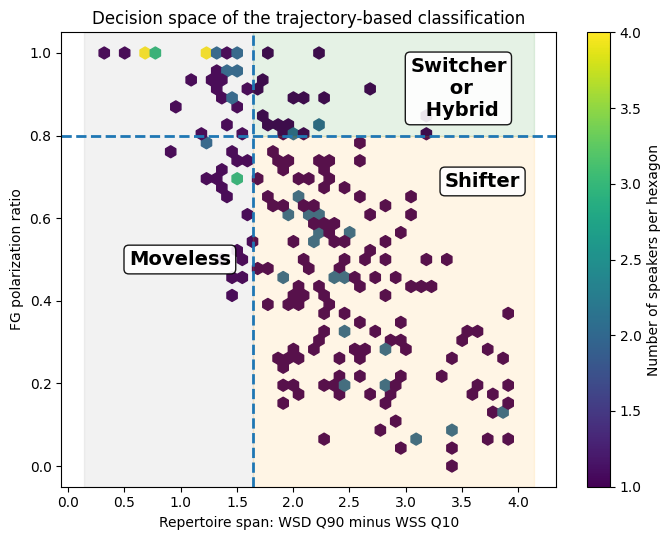

In [ ]:
def plot_classification_space(features: pd.DataFrame) -> None:
    x = features["repertoire_span"]
    y = features["fg_polarization_ratio"]

    fig, ax = plt.subplots(figsize=(7, 5.5))
    density = ax.hexbin(x, y, gridsize=40, mincnt=1, cmap="viridis")
    colorbar = fig.colorbar(density, ax=ax)
    colorbar.set_label("Number of speakers per hexagon")

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    
    ax.axvline(repertoire_span_cutoff, linestyle="--", linewidth=2)
    ax.axhline(FG_POLARIZATION_CUTOFF, linestyle="--", linewidth=2)
    
    ax.axvspan(xmin, repertoire_span_cutoff, alpha=0.10, color="gray")        # Moveless
    ax.axvspan(repertoire_span_cutoff, xmax, ymin=(FG_POLARIZATION_CUTOFF-ymin)/(ymax-ymin), ymax=1, alpha=0.10, color="green")  # Switcher
    ax.axvspan(repertoire_span_cutoff, xmax, ymin=0, ymax=(FG_POLARIZATION_CUTOFF-ymin)/(ymax-ymin), alpha=0.10, color="orange") # Shifter

    label_box = dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="black", alpha=0.9)

    ax.text(
        repertoire_span_cutoff - 0.05 * (xmax - xmin),
        ymin + 0.50 * (ymax - ymin),
        "Moveless",
        ha="right",
        va="center",
        fontsize=14,
        weight="bold",
        bbox=label_box
    )

    ax.text(
        xmax - 0.03 * (xmax - xmin) - 0.55,
        FG_POLARIZATION_CUTOFF + 0.08 * (ymax - ymin) - 0.05,
        "Switcher\n or\n Hybrid",
        ha="center",
        va="bottom",
        fontsize=14,
        weight="bold",
        bbox=label_box
    )

    ax.text(
        xmax - 0.03 * (xmax - xmin),
        FG_POLARIZATION_CUTOFF - 0.08 * (ymax - ymin),
        "Shifter",
        ha="right",
        va="top",
        fontsize=14,
        weight="bold",
        bbox=label_box
    )

    ax.set_xlabel("Repertoire span: WSD Q90 minus WSS Q10")
    ax.set_ylabel("FG polarization ratio")
    ax.set_title("Decision space of the trajectory-based classification")
    fig.tight_layout()

    plt.show()


plot_classification_space(speaker_features)

## 10. Classify speaker profiles

Two classifications are computed separately:

- `speaker_type_recording_level`: conventional classification based on the three condition medians,
- `speaker_type_trajectory`: classification based on repertoire span and FG dynamics.


In [11]:
def classify_recording_level(row: pd.Series) -> str:
    """Classify a speaker from the three recording-level medians."""
    pairwise_differences = [
        abs(row["median_FG"] - row["median_WSS"]),
        abs(row["median_WSD"] - row["median_WSS"]),
        abs(row["median_WSD"] - row["median_FG"]),
    ]

    if any(pd.isna(value) for value in pairwise_differences):
        return "insufficient_data"

    if all(value < recording_median_scale for value in pairwise_differences):
        return "moveless"

    largest_difference = max(pairwise_differences)
    remaining_differences = pairwise_differences.copy()
    remaining_differences.remove(largest_difference)

    if min(remaining_differences) < recording_median_scale:
        return "switcher"
    return "shifter"


def classify_trajectory(row: pd.Series) -> str:
    """Classify a speaker from repertoire span and FG trajectory shape."""
    repertoire_span = row["repertoire_span"]
    polarization = row["fg_polarization_ratio"]
    both_extremes = row["fg_both_extremes"]

    if pd.isna(repertoire_span) or pd.isna(polarization):
        return "insufficient_data"

    if repertoire_span < repertoire_span_cutoff:
        return "moveless"

    if polarization >= FG_POLARIZATION_CUTOFF:
        return "switcher" if bool(both_extremes) else "shifter/switcher"

    return "shifter"


speaker_features["speaker_type_recording_level"] = speaker_features.apply(
    classify_recording_level,
    axis=1,
)
speaker_features["speaker_type_trajectory"] = speaker_features.apply(
    classify_trajectory,
    axis=1,
)

print("Traditional:")
print(speaker_features["speaker_type_recording_level"].value_counts(dropna=False))
print("Temporal:")
print(speaker_features["speaker_type_trajectory"].value_counts(dropna=False))

Traditional:
switcher    152
moveless     69
shifter       9
Name: speaker_type_recording_level, dtype: int64
Temporal:
shifter             152
moveless             58
shifter/switcher     15
switcher              5
Name: speaker_type_trajectory, dtype: int64


## 11. Compare the two classifications

The metrics quantify the formal agreement between the two operationalizations. Neither classification is treated as a gold standard. In particular, the trajectory-based classification contains the additional hybrid category `shifter/switcher`.


In [12]:
classification_comparison = pd.crosstab(
    speaker_features["speaker_type_recording_level"],
    speaker_features["speaker_type_trajectory"],
    margins=True,
)

y_recording = speaker_features["speaker_type_recording_level"]
y_trajectory = speaker_features["speaker_type_trajectory"]

agreement = accuracy_score(y_recording, y_trajectory)
kappa = cohen_kappa_score(y_recording, y_trajectory)
adjusted_rand = adjusted_rand_score(y_recording, y_trajectory)

valid_comparison = (
    y_recording.ne("insufficient_data")
    & y_trajectory.ne("insufficient_data")
)

same_speaker_type = (
    valid_comparison
    & y_recording.eq(y_trajectory)
)

n_same_speaker_type = int(same_speaker_type.sum())
n_valid_speakers = int(valid_comparison.sum())

print(classification_comparison)
print(
    f"Same speaker type:     {n_same_speaker_type} of "
    f"{n_valid_speakers} valid speakers "
    f"({n_same_speaker_type / n_valid_speakers:.1%})"
)
print(f"Exact agreement:       {agreement:.3f}")
print(f"Cohen's κ:             {kappa:.3f}")
print(f"Adjusted Rand Index:   {adjusted_rand:.3f}")

speaker_type_trajectory       moveless  shifter  shifter/switcher  switcher  \
speaker_type_recording_level                                                  
moveless                            46       16                 4         3   
shifter                              0        8                 1         0   
switcher                            12      128                10         2   
All                                 58      152                15         5   

speaker_type_trajectory       All  
speaker_type_recording_level       
moveless                       69  
shifter                         9  
switcher                      152  
All                           230  
Same speaker type:     56 of 230 valid speakers (24.3%)
Exact agreement:       0.243
Cohen's κ:             0.144
Adjusted Rand Index:   0.374


## 12. Save the results


In [ ]:
FEATURES_OUTPUT = OUTPUT_DIR / "speaker_type_features.csv"
SPEAKER_SITUATION_OUTPUT = OUTPUT_DIR / "speaker_situation_scores.csv"

speaker_features.to_csv(FEATURES_OUTPUT, index=False)
speaker_situation_scores.to_csv(SPEAKER_SITUATION_OUTPUT, index=False)

print(f"Saved: {FEATURES_OUTPUT}")
print(f"Saved: {SPEAKER_SITUATION_OUTPUT}")

## 13. Plot 1 — selected FG case studies

Speakers are selected only from the non-moveless part of the decision space (`repertoire_span >= repertoire_span_cutoff`):

1. the speaker with the lowest FG polarization,
2. the speaker closest to the midpoint of the observed polarization range,
3. the most polarized speaker who does **not** reach both extremes,
4. the most polarized speaker who reaches both extremes.

The midpoint in item 2 is the midpoint between the observed minimum and maximum, not the sample median. Each selected speaker is shown in a separate FG-only figure.


In [ ]:
def plot_fg_trajectory(
    frame: pd.DataFrame,
    features: pd.DataFrame,
    speaker: str,
    *,
    case_label: Optional[str] = None,
) -> None:
    """Plot one speaker's FG trajectory relative to individual WSS/WSD medians."""
    group = (
        frame.loc[
            (frame[SPEAKER_COL] == speaker)
            & (frame[SITUATION_COL] == "FG")
        ]
        .sort_values("mid_sec")
        .copy()
    )
    if group.empty:
        raise ValueError(f"No FG segments found for speaker {speaker!r}.")

    feature_rows = features.loc[features[SPEAKER_COL] == speaker]
    if feature_rows.empty:
        raise ValueError(f"No feature row found for speaker {speaker!r}.")
    if len(feature_rows) > 1:
        raise ValueError(f"More than one feature row found for speaker {speaker!r}.")

    feature_row = feature_rows.iloc[0]
    scores = group[SCORE_COL].to_numpy(dtype=float)
    times = group["mid_sec"].to_numpy(dtype=float)

    low_threshold = float(feature_row["speaker_wss_median"])
    high_threshold = float(feature_row["speaker_wsd_median"])

    states, middle_transition, middle_stable = label_fg_states(
        scores,
        low_threshold,
        high_threshold,
    )

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(times, scores, alpha=0.45)
    ax.scatter(
        times[states == "L"],
        scores[states == "L"],
        label="L: close to WSS",
    )
    ax.scatter(
        times[states == "H"],
        scores[states == "H"],
        label="H: close to WSD",
    )
    ax.scatter(
        times[middle_stable],
        scores[middle_stable],
        label="M: stable middle",
    )
    ax.scatter(
        times[middle_transition],
        scores[middle_transition],
        marker="x",
        s=80,
        label="M: transition",
    )

    ax.axhline(low_threshold, linestyle="--", label="WSS median")
    ax.axhline(high_threshold, linestyle="--", label="WSD median")

    title_parts = []
    if case_label is not None:
        title_parts.append(case_label)
    title_parts.append(
        f"{speaker} — {feature_row['speaker_type_trajectory']}"
    )
    ax.set_title(" | ".join(title_parts))
    ax.set_xlabel("Time in FG recording (s)")
    ax.set_ylabel("DIME")
    ax.legend(loc="best")
    fig.tight_layout()
    plt.show()


In [ ]:
def select_fg_case_studies(features: pd.DataFrame) -> pd.DataFrame:
    """Select five targeted FG examples for the qualitative analysis."""
    required_columns = {
        SPEAKER_COL,
        "repertoire_span",
        "fg_polarization_ratio",
        "fg_both_extremes",
        "speaker_type_trajectory",
    }
    missing_columns = required_columns.difference(features.columns)
    if missing_columns:
        raise ValueError(
            f"Missing columns for FG case selection: {sorted(missing_columns)}"
        )

    eligible = features.loc[
        (features["repertoire_span"] >= repertoire_span_cutoff)
        & features["fg_polarization_ratio"].notna()
    ].copy()

    if eligible.empty:
        raise ValueError(
            "No speakers satisfy repertoire_span >= repertoire_span_cutoff."
        )

    selected_rows = []

    def add_selection(label: str, candidates: pd.DataFrame, index: object) -> None:
        if candidates.empty:
            warnings.warn(
                f"No candidate available for case study {label!r}.",
                stacklevel=1,
            )
            return

        row = candidates.loc[index]
        selected_rows.append(
            {
                "case_label": label,
                SPEAKER_COL: row[SPEAKER_COL],
                "speaker_type_trajectory": row["speaker_type_trajectory"],
                "repertoire_span": row["repertoire_span"],
                "fg_polarization_ratio": row["fg_polarization_ratio"],
                "fg_both_extremes": row["fg_both_extremes"],
            }
        )

    # 1. Lowest polarization
    lowest_index = eligible["fg_polarization_ratio"].idxmin()
    add_selection("Lowest polarization", eligible, lowest_index,)

    # 2. Mid-range polarization
    polarization_midpoint = (
        eligible["fg_polarization_ratio"].min()
        + eligible["fg_polarization_ratio"].max()
    ) / 2
    midpoint_index = (
        eligible["fg_polarization_ratio"] - polarization_midpoint
    ).abs().idxmin()
    add_selection("Mid-range polarization", eligible, midpoint_index,)

    # 3. Highest polarization without both extremes
    one_sided_candidates = eligible.loc[
        ~eligible["fg_both_extremes"].fillna(False).astype(bool)
    ]
    if not one_sided_candidates.empty:
        one_sided_index = one_sided_candidates["fg_polarization_ratio"].idxmax()
        add_selection(
            "Highest polarization without both extremes",
            one_sided_candidates,
            one_sided_index,
        )
    else:
        warnings.warn(
            "No eligible speaker without both extremes is available.",
            stacklevel=1,
        )

    # 4. Highest polarization with both extremes
    both_extremes_candidates = eligible.loc[
        eligible["fg_both_extremes"].fillna(False).astype(bool)
    ]
    if not both_extremes_candidates.empty:
        both_extremes_index = both_extremes_candidates[
            "fg_polarization_ratio"
        ].idxmax()
        add_selection(
            "Highest polarization with both extremes",
            both_extremes_candidates,
            both_extremes_index,
        )
    else:
        warnings.warn(
            "No eligible speaker with both extremes is available.",
            stacklevel=1,
        )

       # 5. Speaker for whom all four FG regions are represented:
    # stable middle, transition middle, low extreme, and high extreme.
    all_four_candidates = eligible.loc[
        eligible["fg_both_extremes"].fillna(False).astype(bool)
        & eligible["fg_stable_middle_fraction"].fillna(0).gt(0)
        & eligible["fg_transition_middle_fraction"].fillna(0).gt(0)
    ].copy()

    if not all_four_candidates.empty:
        all_four_candidates["middle_min_fraction"] = all_four_candidates[
            [
                "fg_stable_middle_fraction",
                "fg_transition_middle_fraction",
            ]
        ].min(axis=1)

        all_four_candidates["middle_balance"] = (
            all_four_candidates[
                [
                    "fg_stable_middle_fraction",
                    "fg_transition_middle_fraction",
                ]
            ].min(axis=1)
            / all_four_candidates[
                [
                    "fg_stable_middle_fraction",
                    "fg_transition_middle_fraction",
                ]
            ]
            .max(axis=1)
            .replace(0, np.nan)
        )

        already_selected_speakers = {
            selected_row[SPEAKER_COL]
            for selected_row in selected_rows
        }

        unique_all_four_candidates = all_four_candidates.loc[
            ~all_four_candidates[SPEAKER_COL].isin(
                already_selected_speakers
            )
        ]

        if not unique_all_four_candidates.empty:
            all_four_candidates = unique_all_four_candidates

        all_four_index = (
            all_four_candidates.sort_values(
                by=[
                    "middle_min_fraction",
                    "middle_balance",
                    "repertoire_span",
                    "fg_polarization_ratio",
                ],
                ascending=[False, False, False, False],
            )
            .index[0]
        )

        add_selection(
            "All four FG regions",
            all_four_candidates,
            all_four_index,
        )
    else:
        warnings.warn(
            "No eligible speaker has both extremes as well as positive "
            "stable-middle and transition-middle fractions.",
            stacklevel=1,
        )

    return pd.DataFrame(selected_rows)


fg_case_studies = select_fg_case_studies(speaker_features)
fg_case_studies


,case_label,speaker,speaker_type_trajectory,repertoire_span,fg_polarization_ratio,fg_both_extremes
0,Lowest polarization,HB1,shifter,3.367461,0.000000,False
1,Mid-range polarization,AN3,shifter,2.055416,0.500000,False
2,Highest polarization without both extremes,DM1,shifter/switcher,1.735037,1.000000,False
3,Highest polarization with both extremes,VSALT1,switcher,1.753748,0.928571,True
4,All four FG regions,WUEALT,switcher,1.843632,0.833333,True


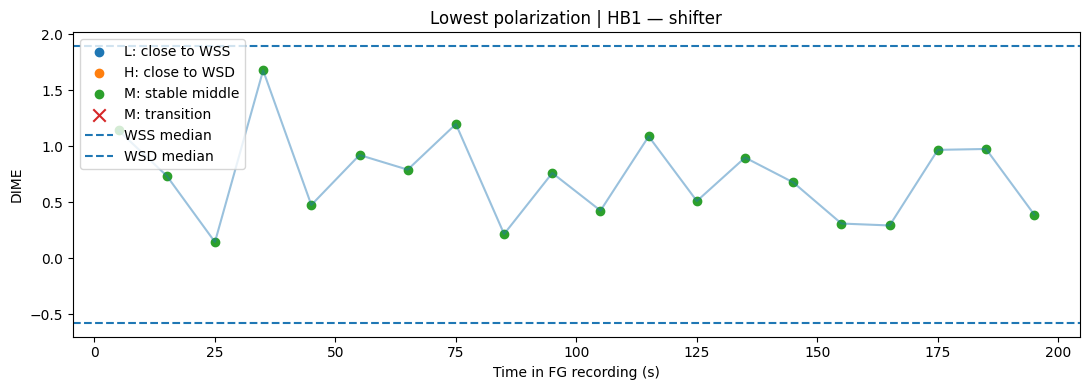

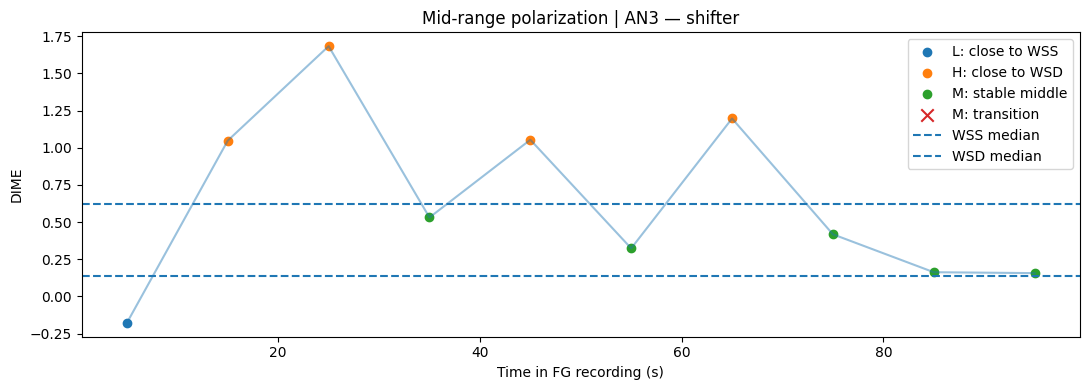

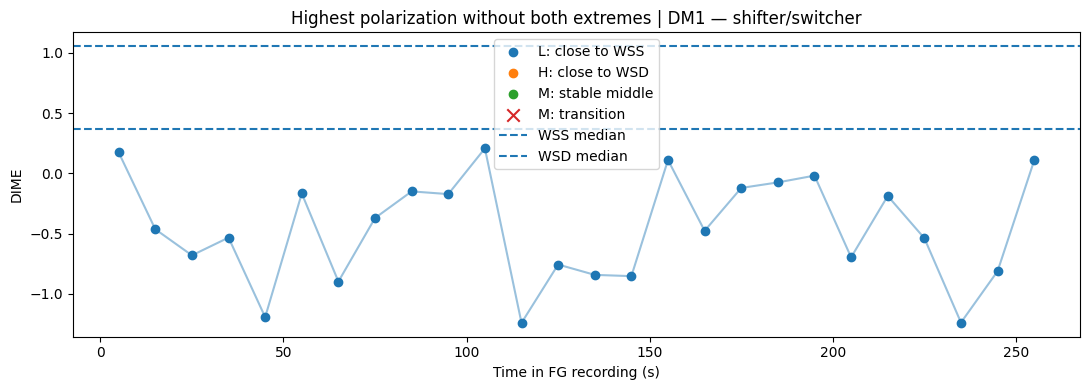

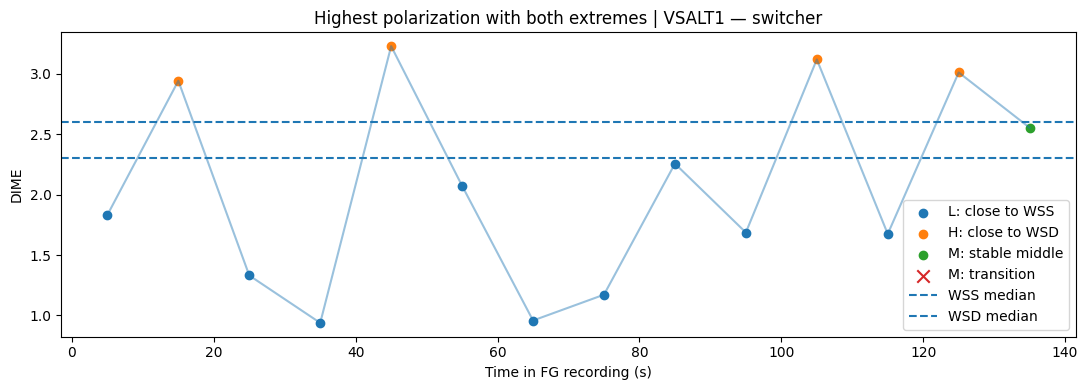

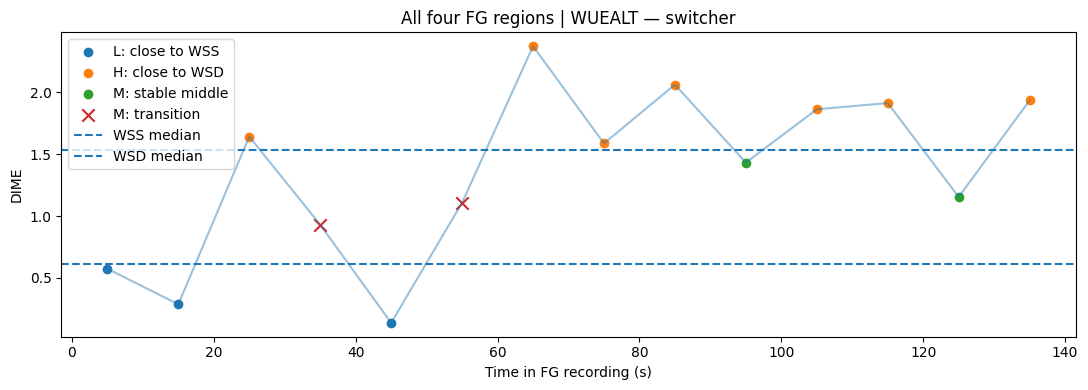

In [16]:
for case in fg_case_studies.itertuples(index=False):
    plot_fg_trajectory(
        segments,
        speaker_features,
        getattr(case, SPEAKER_COL),
        case_label=case.case_label,
    )


## 14. Plot 2 — illustrative speakers for each trajectory-based type

This visualization selects one particularly clear example for each trajectory-based
speaker type. The selected speakers are intended as **illustrative cases**, not as
statistically representative members of their respective groups.

The selection uses both the formal classification features and the visual separation
between the speaker-specific WSS and WSD reference distributions.

For the non-moveless types, speakers with comparatively large repertoire spans and
clear WSS–WSD median separation are preferred before the final selection score is
computed.

The type-specific selection criteria are:

- **moveless:** small repertoire span and small WSS–WSD median separation;
- **shifter:** large repertoire span, clear median separation, and low FG polarization;
- **shifter/switcher:** large repertoire span, clear median separation, high FG
  polarization, and a strongly one-sided realization of the two FG extremes;
- **switcher:** large repertoire span, clear median separation, high FG polarization,
  and substantial realization of both FG extremes.

The selection score is computed within each speaker type. It is therefore useful for
ranking speakers within a type, but scores should not be compared across types.

In [17]:
def compute_fg_extreme_profiles(
    frame: pd.DataFrame,
    features: pd.DataFrame,
) -> pd.DataFrame:
    """Compute the distribution of low and high FG states for each speaker."""
    feature_index = features.set_index(SPEAKER_COL)
    rows = []

    fg_segments = frame.loc[
        frame[SITUATION_COL] == "FG"
    ]

    for speaker, group in fg_segments.groupby(SPEAKER_COL):
        if speaker not in feature_index.index:
            continue

        feature_row = feature_index.loc[speaker]

        if isinstance(feature_row, pd.DataFrame):
            raise ValueError(
                f"More than one feature row found for speaker {speaker!r}."
            )

        scores = (
            group
            .sort_values("mid_sec")[SCORE_COL]
            .to_numpy(dtype=float)
        )

        states, _, _ = label_fg_states(
            scores,
            low_threshold=float(feature_row["speaker_wss_median"]),
            high_threshold=float(feature_row["speaker_wsd_median"]),
        )

        low_fraction = float(np.mean(states == "L"))
        high_fraction = float(np.mean(states == "H"))
        total_extreme_fraction = low_fraction + high_fraction

        if total_extreme_fraction > 0:
            extreme_balance = (
                1.0
                - abs(low_fraction - high_fraction)
                / total_extreme_fraction
            )
            extreme_one_sidedness = (
                abs(low_fraction - high_fraction)
                / total_extreme_fraction
            )
        else:
            extreme_balance = 0.0
            extreme_one_sidedness = 0.0

        # This value is high only when both extremes occur frequently.
        both_extremes_strength = 2.0 * min(
            low_fraction,
            high_fraction,
        )

        # This value represents the more frequently used FG extreme.
        dominant_extreme_fraction = max(
            low_fraction,
            high_fraction,
        )

        rows.append(
            {
                SPEAKER_COL: speaker,
                "fg_low_fraction": low_fraction,
                "fg_high_fraction": high_fraction,
                "fg_total_extreme_fraction": total_extreme_fraction,
                "fg_extreme_balance": extreme_balance,
                "fg_extreme_one_sidedness": extreme_one_sidedness,
                "fg_both_extremes_strength": both_extremes_strength,
                "fg_dominant_extreme_fraction": dominant_extreme_fraction,
            }
        )

    return pd.DataFrame(rows)

def percentile_preference(
    values: pd.Series,
    higher_is_better: bool,
) -> pd.Series:
    """Convert a feature into a percentile-based preference score."""
    numeric_values = pd.to_numeric(
        values,
        errors="coerce",
    )

    if higher_is_better:
        ranked_values = numeric_values
    else:
        ranked_values = -numeric_values

    return (
        ranked_values
        .rank(method="average", pct=True)
        .fillna(0.0)
    )


def restrict_to_visually_clear_non_moveless_cases(
    group: pd.DataFrame,
) -> pd.DataFrame:
    """
    Prefer speakers with a large repertoire span and clear WSS–WSD
    median separation.

    The filtering is applied stepwise so that a candidate remains
    available even for small speaker-type groups.
    """
    candidates = group.copy()

    positive_separation = candidates.loc[
        candidates["median_separation"] > 0
    ]

    if not positive_separation.empty:
        candidates = positive_separation

    if len(candidates) > 1:
        span_threshold = candidates["repertoire_span"].median()

        large_span_candidates = candidates.loc[
            candidates["repertoire_span"] >= span_threshold
        ]

        if not large_span_candidates.empty:
            candidates = large_span_candidates

    if len(candidates) > 1:
        separation_threshold = candidates[
            "median_separation"
        ].median()

        clearly_separated_candidates = candidates.loc[
            candidates["median_separation"]
            >= separation_threshold
        ]

        if not clearly_separated_candidates.empty:
            candidates = clearly_separated_candidates

    return candidates


def select_illustrative_speakers(
    frame: pd.DataFrame,
    features: pd.DataFrame,
) -> pd.DataFrame:
    """
    Select one visually clear example for each trajectory-based speaker type.
    """
    extreme_profiles = compute_fg_extreme_profiles(
        frame,
        features,
    )

    candidates = features.merge(
        extreme_profiles,
        on=SPEAKER_COL,
        how="left",
        validate="one_to_one",
    )

    # Median separation is visually more directly interpretable than
    # the quantile-based repertoire span alone.
    candidates["median_separation"] = (
        candidates["speaker_wsd_median"]
        - candidates["speaker_wss_median"]
    )

    type_order = [
        "moveless",
        "shifter",
        "shifter/switcher",
        "switcher",
    ]

    selected_rows = []

    for speaker_type in type_order:
        type_candidates = candidates.loc[
            candidates["speaker_type_trajectory"] == speaker_type
        ].copy()

        if type_candidates.empty:
            warnings.warn(
                f"No speaker is available for type {speaker_type!r}.",
                stacklevel=1,
            )
            continue

        # Moveless speakers should show both a small quantile-based
        # repertoire and little separation between the two medians.
        if speaker_type == "moveless":
            span_small = percentile_preference(
                type_candidates["repertoire_span"],
                higher_is_better=False,
            )
            separation_small = percentile_preference(
                type_candidates["median_separation"].abs(),
                higher_is_better=False,
            )

            type_candidates["illustrative_score"] = (
                0.50 * span_small
                + 0.50 * separation_small
            )

        else:
            # For all non-moveless types, first prefer speakers for whom
            # the repertoire difference is also visually apparent.
            type_candidates = (
                restrict_to_visually_clear_non_moveless_cases(
                    type_candidates
                )
            )

            span_large = percentile_preference(
                type_candidates["repertoire_span"],
                higher_is_better=True,
            )
            separation_large = percentile_preference(
                type_candidates["median_separation"],
                higher_is_better=True,
            )
            polarization_high = percentile_preference(
                type_candidates["fg_polarization_ratio"],
                higher_is_better=True,
            )

            if speaker_type == "shifter":
                polarization_low = percentile_preference(
                    type_candidates["fg_polarization_ratio"],
                    higher_is_better=False,
                )

                type_candidates["illustrative_score"] = (
                    0.35 * span_large
                    + 0.35 * separation_large
                    + 0.30 * polarization_low
                )

            elif speaker_type == "shifter/switcher":
                one_sidedness_high = percentile_preference(
                    type_candidates["fg_extreme_one_sidedness"],
                    higher_is_better=True,
                )
                dominant_extreme_high = percentile_preference(
                    type_candidates["fg_dominant_extreme_fraction"],
                    higher_is_better=True,
                )

                type_candidates["illustrative_score"] = (
                    0.25 * span_large
                    + 0.25 * separation_large
                    + 0.20 * polarization_high
                    + 0.15 * one_sidedness_high
                    + 0.15 * dominant_extreme_high
                )

            elif speaker_type == "switcher":
                both_extremes_high = percentile_preference(
                    type_candidates["fg_both_extremes_strength"],
                    higher_is_better=True,
                )
                balance_high = percentile_preference(
                    type_candidates["fg_extreme_balance"],
                    higher_is_better=True,
                )

                type_candidates["illustrative_score"] = (
                    0.20 * span_large
                    + 0.20 * separation_large
                    + 0.20 * polarization_high
                    + 0.25 * both_extremes_high
                    + 0.15 * balance_high
                )

        best_row = (
            type_candidates
            .sort_values(
                ["illustrative_score", SPEAKER_COL],
                ascending=[False, True],
            )
            .iloc[0]
        )

        selected_rows.append(best_row)

    if not selected_rows:
        return pd.DataFrame()

    selected = pd.DataFrame(selected_rows)

    selected["speaker_type_trajectory"] = pd.Categorical(
        selected["speaker_type_trajectory"],
        categories=type_order,
        ordered=True,
    )

    return (
        selected
        .sort_values("speaker_type_trajectory")
        .reset_index(drop=True)
    )


illustrative_speakers = select_illustrative_speakers(
    segments,
    speaker_features,
)

selection_columns = [
    SPEAKER_COL,
    "speaker_type_trajectory",
    "illustrative_score",
    "repertoire_span",
    "median_separation",
    "fg_polarization_ratio",
    "fg_low_fraction",
    "fg_high_fraction",
    "fg_both_extremes_strength",
    "fg_extreme_balance",
    "fg_extreme_one_sidedness",
]

illustrative_speakers[selection_columns]


,speaker,speaker_type_trajectory,illustrative_score,repertoire_span,median_separation,fg_polarization_ratio,fg_low_fraction,fg_high_fraction,fg_both_extremes_strength,fg_extreme_balance,fg_extreme_one_sidedness
0,COE1,moveless,0.991379,0.502668,-0.006713,1.000000,0.148148,0.851852,0.296296,0.296296,0.703704
1,K16,shifter,0.940789,3.957608,2.568576,0.068966,0.068966,0.000000,0.000000,0.000000,1.000000
2,AMJUNG1,shifter/switcher,0.931250,3.227961,1.504248,0.846154,0.846154,0.000000,0.000000,0.000000,1.000000
3,BUD3,switcher,0.800000,2.308225,0.713551,0.888889,0.600000,0.200000,0.400000,0.500000,0.500000


### Visualization of the selected speakers

For each selected speaker, WSS, WSD, and FG are shown as separate recording
trajectories.

Two different speaker-specific reference ranges are visualized:

- the shaded area represents the quantile-based repertoire from WSS Q10 to WSD Q90;
- the horizontal lines represent the WSS and WSD medians used to assign FG segments
  to the low, middle, and high states.

The quantile range corresponds to the `repertoire_span` used for the moveless versus
non-moveless distinction. The medians correspond to the thresholds used for the
analysis of FG polarization.

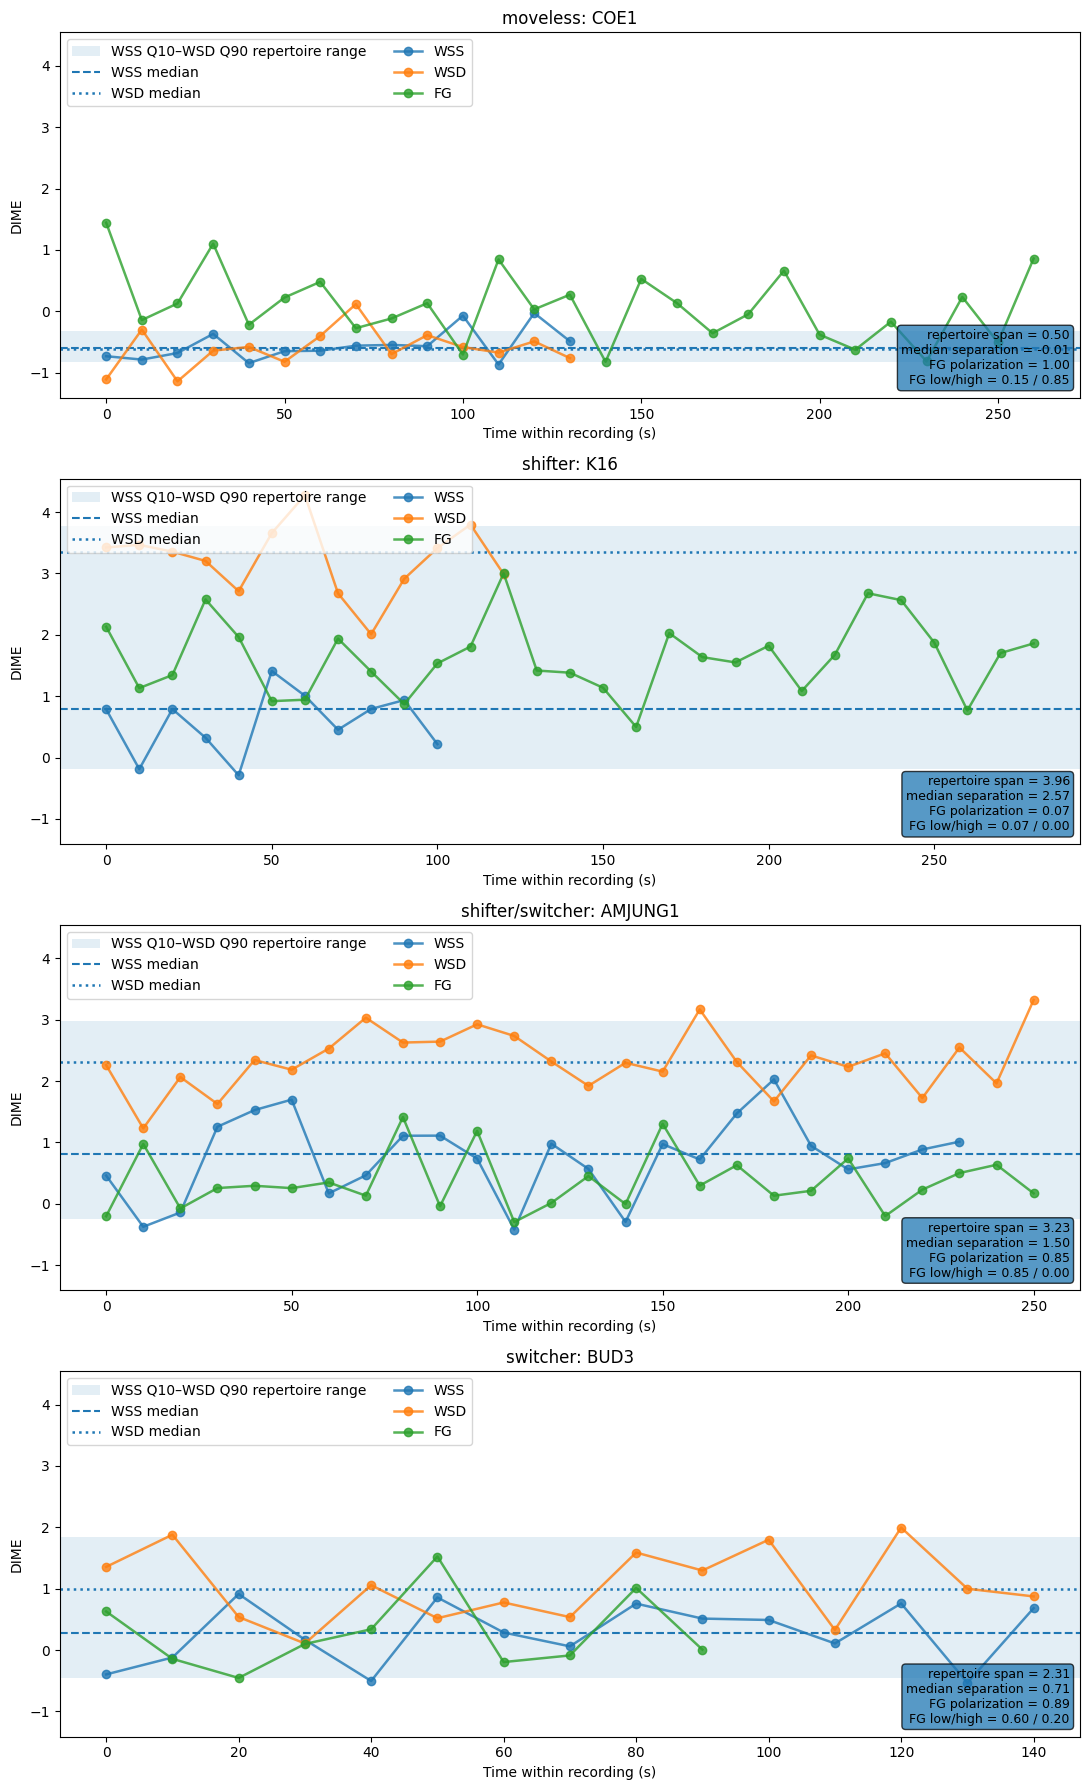

In [ ]:
def plot_illustrative_speaker_trajectories(
    frame: pd.DataFrame,
    selected_speakers: pd.DataFrame,
) -> None:
    """
    Plot WSS, WSD, and FG trajectories for one illustrative speaker per type.
    """
    if selected_speakers.empty:
        raise ValueError(
            "No illustrative speakers were selected."
        )

    figure, axes = plt.subplots(
        nrows=len(selected_speakers),
        ncols=1,
        figsize=(11, 4.5 * len(selected_speakers)),
        sharey=True,
        squeeze=False,
    )

    for axis, (_, speaker_row) in zip(
        axes[:, 0],
        selected_speakers.iterrows(),
    ):
        speaker = speaker_row[SPEAKER_COL]
        speaker_type = speaker_row[
            "speaker_type_trajectory"
        ]

        speaker_segments = (
            frame.loc[frame[SPEAKER_COL] == speaker]
            .copy()
            .sort_values(
                [SITUATION_COL, "mid_sec"]
            )
        )

        wss_q10 = float(
            speaker_row["speaker_wss_q10"]
        )
        wsd_q90 = float(
            speaker_row["speaker_wsd_q90"]
        )
        wss_median = float(
            speaker_row["speaker_wss_median"]
        )
        wsd_median = float(
            speaker_row["speaker_wsd_median"]
        )

        # Use min/max defensively in case the empirical poles occur
        # in an unexpected order for an individual speaker.
        repertoire_lower = min(
            wss_q10,
            wsd_q90,
        )
        repertoire_upper = max(
            wss_q10,
            wsd_q90,
        )

        axis.axhspan(
            repertoire_lower,
            repertoire_upper,
            alpha=0.12,
            label="WSS Q10–WSD Q90 repertoire range",
        )

        axis.axhline(
            wss_median,
            linestyle="--",
            linewidth=1.5,
            label="WSS median",
        )
        axis.axhline(
            wsd_median,
            linestyle=":",
            linewidth=1.8,
            label="WSD median",
        )

        for situation in VALID_SITUATIONS:
            condition_segments = (
                speaker_segments.loc[
                    speaker_segments[SITUATION_COL]
                    == situation
                ]
                .sort_values("mid_sec")
                .copy()
            )

            if condition_segments.empty:
                continue

            elapsed_time = (
                condition_segments["mid_sec"]
                - condition_segments["mid_sec"].min()
            )

            axis.plot(
                elapsed_time,
                condition_segments[SCORE_COL],
                marker="o",
                linewidth=1.8,
                alpha=0.8,
                label=situation,
            )

        axis.set_title(
            f"{speaker_type}: {speaker}"
        )
        axis.set_xlabel(
            "Time within recording (s)"
        )
        axis.set_ylabel("DIME")

        metric_text = (
            f"repertoire span = "
            f"{speaker_row['repertoire_span']:.2f}\n"
            f"median separation = "
            f"{speaker_row['median_separation']:.2f}\n"
            f"FG polarization = "
            f"{speaker_row['fg_polarization_ratio']:.2f}\n"
            f"FG low/high = "
            f"{speaker_row['fg_low_fraction']:.2f} / "
            f"{speaker_row['fg_high_fraction']:.2f}"
        )

        axis.text(
            0.99,
            0.03,
            metric_text,
            transform=axis.transAxes,
            horizontalalignment="right",
            verticalalignment="bottom",
            fontsize=9,
            bbox={
                "boxstyle": "round",
                "alpha": 0.75,
            },
        )

        axis.legend(
            loc="upper left",
            ncol=2,
        )

    figure.tight_layout()
    plt.show()


plot_illustrative_speaker_trajectories(
    segments,
    illustrative_speakers,
)


## 15. Distribution of speaker types by dialect region

When a speaker ID is associated with more than one dialect label, a warning is issued and the first label is used. This prevents feature rows from being duplicated by a many-to-many merge.


In [19]:
def attach_one_dialect_per_speaker(
    features: pd.DataFrame,
    frame: pd.DataFrame,
) -> pd.DataFrame:
    """Attach one dialect label per speaker without duplicating feature rows."""
    if DIALECT_COL not in frame.columns:
        raise ValueError(f"The following column is required for this analysis {DIALECT_COL!r}.")

    dialect_counts = frame.groupby(SPEAKER_COL)[DIALECT_COL].nunique(dropna=True)
    ambiguous_speakers = dialect_counts[dialect_counts > 1]
    if not ambiguous_speakers.empty:
        warnings.warn(
            f"{len(ambiguous_speakers)} speakers have multiple dialect labels; "
            "the first value is used for the descriptive analysis.",
            stacklevel=1,
        )

    speaker_dialect = (
        frame.dropna(subset=[DIALECT_COL])
        .groupby(SPEAKER_COL, as_index=False)[DIALECT_COL]
        .first()
    )
    return features.merge(speaker_dialect, on=SPEAKER_COL, how="left", validate="one_to_one")


features_with_dialect = attach_one_dialect_per_speaker(speaker_features, segments)

type_counts_by_dialect = (
    features_with_dialect
    .groupby([DIALECT_COL, "speaker_type_trajectory"])
    .size()
    .reset_index(name="n_speakers")
)
type_counts_by_dialect["percent"] = (
    type_counts_by_dialect["n_speakers"]
    / type_counts_by_dialect.groupby(DIALECT_COL)["n_speakers"].transform("sum")
    * 100
)

type_counts_by_dialect.sort_values([DIALECT_COL, "speaker_type_trajectory"])

,dialect,speaker_type_trajectory,n_speakers,percent
0,Bavarian,shifter,17,89.473684
1,Bavarian,shifter/switcher,2,10.526316
2,Brandenburgian,moveless,3,60.000000
3,Brandenburgian,shifter,1,20.000000
4,Brandenburgian,shifter/switcher,1,20.000000
5,Central Hessian,moveless,2,16.666667
6,Central Hessian,shifter,7,58.333333
7,Central Hessian,shifter/switcher,2,16.666667
8,Central Hessian,switcher,1,8.333333
9,East Franconian,moveless,8,36.363636


## 16. Notes on interpretation

- The thresholds are dataset-dependent operationalizations rather than universal linguistic constants.
- Segment values from the same speaker and recording are statistically dependent.
- Polarization captures the observed FG realization relative to the individual WSS and WSD references; it is not a direct measure of underlying competence.
- The hybrid category denotes high polarization without sufficient proportions at both extremes.
